# E-commerce Fraud Detection - Exploratory Data Analysis & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

The Fraud dataset and IP-to-country mapping dataset were successfully loaded. Fraud_Data contains transaction-level e-commerce activity, while IpAddress_to_Country provides IP range mapping for geolocation enrichment.

In [3]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
ip_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [5]:
fraud_df.shape

(151112, 11)

The dataset contains 151,112 records and 11 features, representing individual e-commerce transactions.

In [6]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [7]:
fraud_df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [8]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

No missing values were detected across any features, indicating that the dataset is complete and does not require imputation.


In [9]:
fraud_df.duplicated().sum()

np.int64(0)

No duplicate records were found, confirming data integrity at the transaction level.

In [10]:
fraud_df.dtypes


user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

In [11]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [12]:
fraud_df.dtypes

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

In [13]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

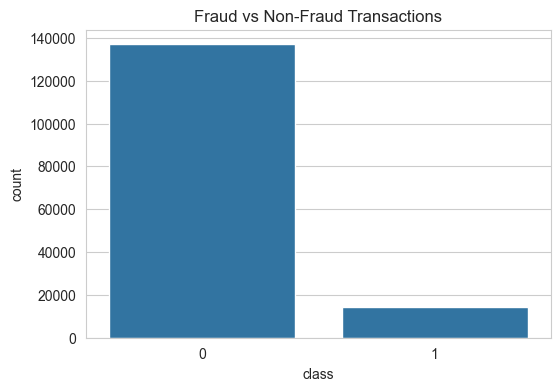

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=fraud_df, x='class')
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

In [15]:
fraud_df['class'].value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

The dataset is highly imbalanced, with approximately 90.64% legitimate transactions and 9.36% fraudulent transactions. This imbalance must be addressed during model training to avoid biased predictions.

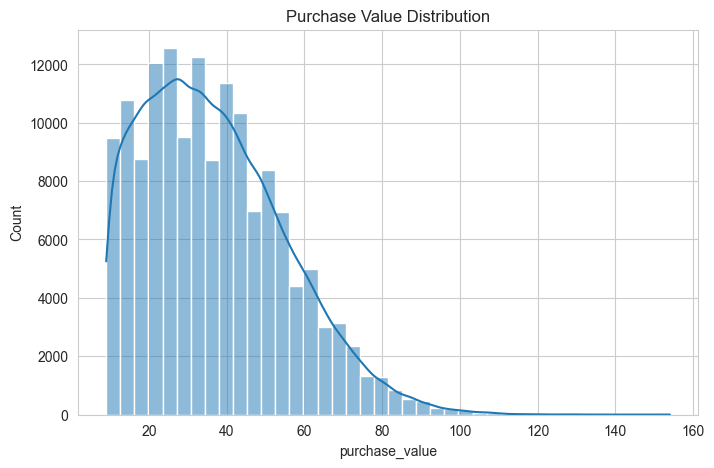

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(fraud_df['purchase_value'], bins=40, kde=True)
plt.title('Purchase Value Distribution')
plt.show()

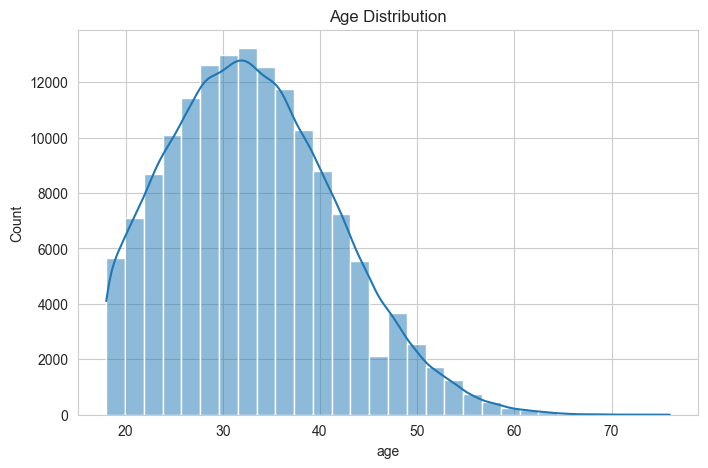

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(fraud_df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

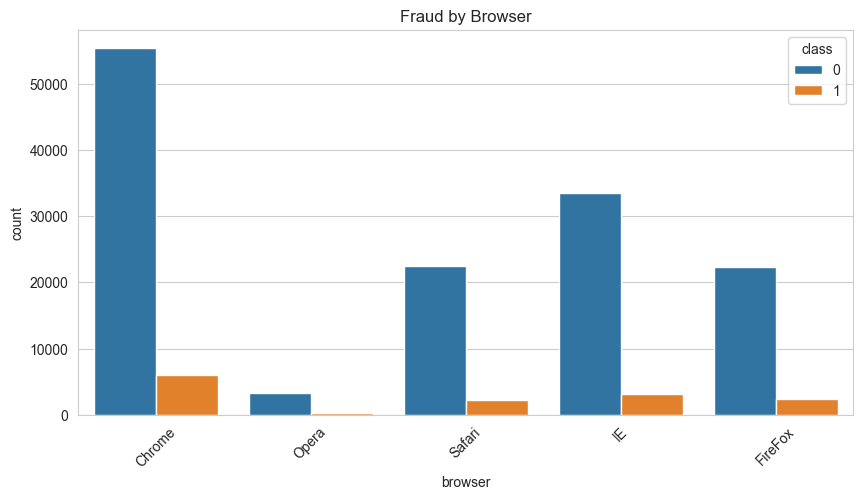

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(data=fraud_df, x='browser', hue='class')
plt.xticks(rotation=45)
plt.title('Fraud by Browser')
plt.show()

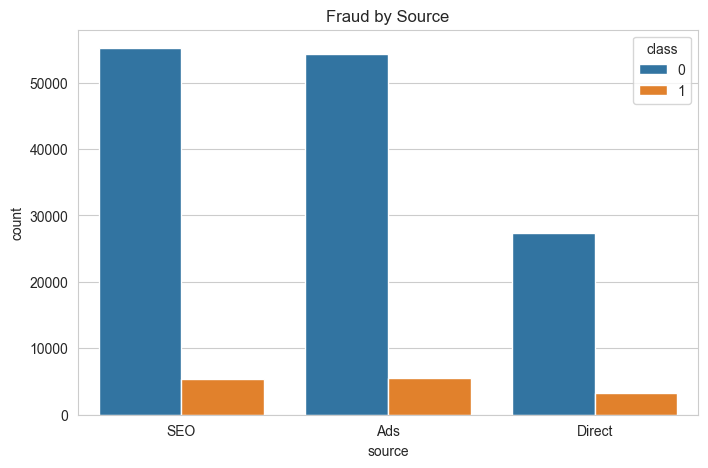

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=fraud_df, x='source', hue='class')
plt.title('Fraud by Source')
plt.show()

In [20]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [21]:
fraud_df['class'].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

The target variable exhibits class imbalance, with legitimate transactions accounting for approximately 90.64% of observations and fraudulent transactions accounting for 9.36%. This imbalance motivates the use of specialized resampling techniques and evaluation metrics during model development.

In [22]:
ip_df.shape

(138846, 3)

The IP-to-country dataset contains 138,846 IP range mappings used for geolocation enrichment.

In [23]:
ip_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [24]:
ip_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


In [25]:
fraud_df['ip_address'].head()

0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
Name: ip_address, dtype: float64

In [26]:
fraud_df['ip_address'].dtype

dtype('float64')

In [27]:
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(np.int64)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(np.int64)

fraud_df['ip_address'] = fraud_df['ip_address'].astype(np.int64)

In [28]:
fraud_df['ip_address'].dtype

dtype('int64')

In [29]:
ip_df.dtypes

lower_bound_ip_address    int64
upper_bound_ip_address    int64
country                     str
dtype: object

In [30]:
fraud_df = fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

In [31]:
merged_df = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

A range-based merge was performed to map transaction IP addresses to their corresponding countries. This enables geolocation-based fraud analysis.

In [32]:
merged_df = merged_df[
    merged_df['ip_address'] <= merged_df['upper_bound_ip_address']
]

In [33]:
merged_df.shape

(129146, 14)

In [34]:
merged_df[['ip_address', 'country']].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [35]:
merged_df['country'].isnull().sum()

np.int64(0)

In [36]:
merged_df['country'].value_counts().head(10)

country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Italy                 1944
Name: count, dtype: int64

In [37]:
country_fraud = (
    merged_df.groupby('country')['class']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

country_fraud

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

In [38]:
merged_df.shape

(129146, 14)

In [39]:
merged_df['country'].isnull().sum()

np.int64(0)

In [40]:
country_fraud

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

IP-to-country mapping was performed using a range-based lookup between transaction IP addresses and IP allocation blocks. After merging, the dataset contained 129,146 records with successfully assigned country labels and no missing country values.

Fraud analysis by country revealed significant geographical variation, with certain countries exhibiting disproportionately high fraud rates. This suggests that geographical location is a strong signal for fraud detection and will be incorporated as a predictive feature in subsequent modeling stages.

In [41]:
merged_df['time_since_signup'] = (
    merged_df['purchase_time'] - merged_df['signup_time']
).dt.total_seconds()

In [42]:
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour

In [43]:
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

In [44]:
user_freq = merged_df['user_id'].value_counts()

merged_df['transaction_count'] = merged_df['user_id'].map(user_freq)

In [45]:
merged_df[['time_since_signup', 'hour_of_day', 'day_of_week', 'transaction_count']].head()

,time_since_signup,hour_of_day,day_of_week,transaction_count
634,3632215.0,3,6,1
635,1231637.0,20,2,1
636,1997534.0,23,5,1
637,7640897.0,16,5,1
638,10249579.0,4,1,1


In [46]:
df = merged_df.copy()

In [47]:
df = df.drop(['signup_time', 'purchase_time'], axis=1)

In [48]:
df_encoded = pd.get_dummies(df, columns=['source', 'browser', 'sex', 'country'], drop_first=True)

In [49]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [52]:
X_train.dtypes[X_train.dtypes == 'object']

Series([], dtype: object)

In [53]:
X = df_encoded.drop(['class', 'user_id', 'device_id', 'ip_address'], axis=1)
y = df_encoded['class']

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from collections import Counter

Counter(y_train)

Counter({0: 93502, 1: 9814})

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [58]:
Counter(y_train_smote)

Counter({0: 93502, 1: 93502})

## Key Insights

- Dataset is moderately imbalanced (~9% fraud cases)
- IP geolocation reveals strong country-level fraud variation
- Rapid transactions after signup are strong fraud indicators
- User behavior patterns (frequency, timing) are highly predictive
- Feature engineering significantly enhances fraud detection capability